# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [208]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [209]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [210]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [211]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [212]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [213]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [214]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [215]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [216]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [217]:
# cantidad de nulos para users
print("Cantidad de valores nulos", users.isna().count())
print("Proporción de valores nulos", users.isna().mean())

Cantidad de valores nulos user_id       4000
first_name    4000
last_name     4000
age           4000
city          4000
reg_date      4000
plan          4000
churn_date    4000
dtype: int64
Proporción de valores nulos user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [218]:
# cantidad de nulos para usage
print("Cantidad de valores nulos", usage.isna().count())
print("Proporción de valores nulos", usage.isna().mean())

Cantidad de valores nulos id          40000
user_id     40000
type        40000
date        40000
duration    40000
length      40000
dtype: int64
Proporción de valores nulos id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

**Respuesta**: el dataset users tiene valores ausentes city (.11%) y churn_date (.88%); la columna churn_date se puede ignorar o eliminar por completo, columna city revisar únicos y revisar porque son nulos.

El dataset de usage, en la columna de date tien un porcentaje muy bajo, solo dar una simple revisada determinar si es nulo o un registro mal capturado. la columna duration (.55%) revisar nulos probablemte sea info sin formato y la columna length (.44%) de igual forma revisar los nulos probablemente sea info sin formato correcto. 

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [219]:
# explorar columnas numéricas de users
numericas_user = users[["user_id", "age"]].describe()
print("Columnas númericas users: \n", numericas_user)

Columnas númericas users: 
             user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` no tiene sentinels.
- La columna `age` tiene un sentinel (-999) y tiene una desviación alta probablemente por el -999.

In [220]:
# explorar columnas numéricas de usage
numericas_usage = usage[["id", "user_id"]].describe() 
print("Columnas númericas usage: \n", numericas_usage)

Columnas númericas usage: 
                 id       user_id
count  40000.00000  40000.000000
mean   20000.50000  12002.405975
std    11547.14972   1157.279564
min        1.00000  10000.000000
25%    10000.75000  10996.000000
50%    20000.50000  12013.000000
75%    30000.25000  13005.000000
max    40000.00000  13999.000000


- Las columnas `id` revisar la desviación.
- Las columnas `user_id`no tiene sentinels.

In [221]:
# explorar columnas categóricas de users
categoricas_city = users['city'].describe()
categoricas_plan = users["plan"].describe()
print("Categoricas city: \n", categoricas_city, "\nÚnicos: \n", users["city"].unique())
print("Categoricas city: \n", categoricas_plan, "\nÚnicos: \n", users["plan"].unique())



Categoricas city: 
 count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object 
Únicos: 
 ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Categoricas city: 
 count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object 
Únicos: 
 ['Basico' 'Premium']


- La columna `city` tiene sentinels (?), nulos, dar formato al texto para estandarizar.
- La columna `plan` esta bien, no tiene sentinels.

In [222]:
# explorar columna categórica de usage
categorica_usage = usage['type'].describe()# completa el código
print("Categoricas usage: \n", categorica_usage)

Categoricas usage: 
 count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type` no tiene sentinels.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

- en AGE hay sentinels que se deben de corregir. ID revisar la desviación. CITY hay sentiels a corregir..


- ¿Qué acción tomarías?

- EN AGE coreggir los sentinels usando media. en City revisar el sentinels y corregir dependiendo el metodo que le aplique y dar formato al texto para estandarizar la info de la columna.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [223]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce") # completa el código

In [224]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce")# completa el código

In [225]:
# Revisar los años presentes en `reg_date` de users
print("AÑOS \n", users["reg_date"].dt.year.value_counts())

AÑOS 
 2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, hay 40 fechas imposibles que corresponden al 2026.

In [226]:
# Revisar los años presentes en `date` de usage
print("AÑOS \n", usage["date"].dt.year.value_counts())

AÑOS 
 2024.0    39950
Name: date, dtype: int64


En `date`, hay 50 registros sin año, los demas todos corresponden al 2024.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Si, aparece el 2026. en la columna reg_date, del datset users.
- En el dataset usage, la columna date tiene 50 registros sin año.

  
- ¿Qué harías con ellas?
- Pare el dataset users columna req_date, eliminaria esos registros ya que en este caso ese año aun no existe y hay registrios de años pasados, por lo tanto eliminaria esos registros en lugar de cambiar el año por la mediana.
- Para el dataset usage, en la columna date, al ver que solo existe un año, le asiganría ese mismo año a los registros que les falta.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [227]:
# Reemplazar -999 por la mediana de age
age_sin_sentinels = (users["age"] > 0) & (users["age"] <=79)
age_mediana = users["age"][age_sin_sentinels].median()
users['age'] = users["age"].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [228]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [229]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year == 2026, "reg_date"]=pd.NaT


# Verificar cambios
users["reg_date"].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [230]:
# Verificación MAR en usage (Missing At Random) para duration
missing_duration = usage["duration"].isna().groupby(usage["type"]).mean()

print("MAR \n", missing_duration)

MAR 
 type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [231]:
# Verificación MAR en usage (Missing At Random) para length
missing_length = usage["length"].isna().groupby(usage["type"]).mean()

print("MAR \n", missing_length)

MAR 
 type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Si son MAR, ya que en el caso de duration son nulos que no afectan, ya que revisnado con type vemos que solo aplican para la categoria text, la cual no se mide por duración por eso no afecta que no tenga un valor.
y en el caso de lenght vemos que los nulos aparecen en call, porque esta no se mide por longitud y por lo tanto no afecta la falta de valor.

en conclusión al no afectar se dejan como nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [232]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    total_de_mensajes =("is_text", "sum"),
    total_de_llamadas = ("is_call", "sum"),
    total_de_minutos =("duration", "sum")).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,total_de_mensajes,total_de_llamadas,total_de_minutos
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [233]:
# Renombrar columnas
usage_agg.rename(columns={"total_de_mensajes": "cant_mensajes", "total_de_llamadas": "cant_llamadas", "total_de_minutos": "cant_minutos_llamada"}, inplace=True)
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [234]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users, on="user_id")
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [235]:
# Resumen estadístico de las columnas numéricas
user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada", "age"]].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054,48.138285
std,2.358416,2.144238,18.168095,17.691541
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,48.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [236]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

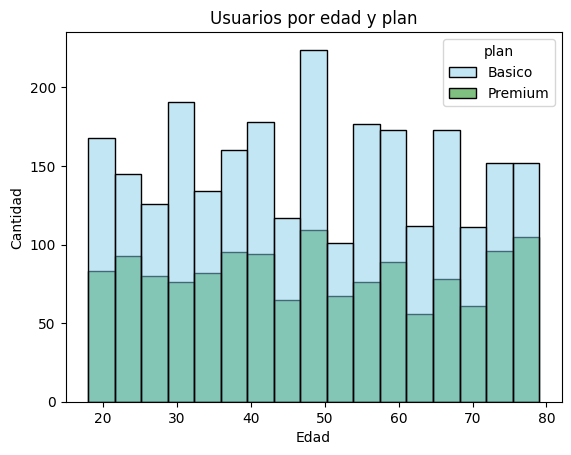

In [237]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x= "age", hue="plan", palette=["skyblue", "green"])
plt.title("Usuarios por edad y plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.show()

💡Insights: 
- plan básico representa el 65% de usuarios.
- plan premium representa el 25% de usuarios.

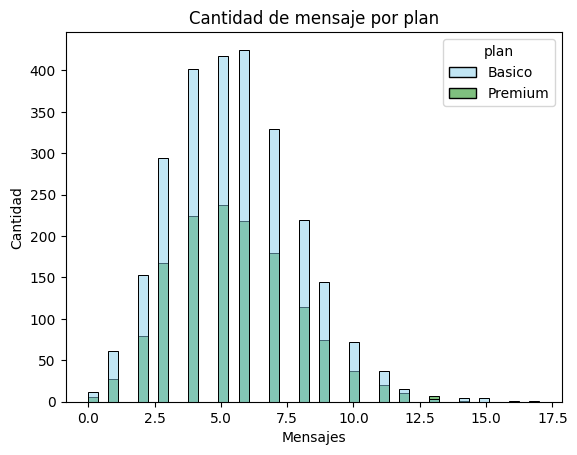

In [238]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x= "cant_mensajes", hue="plan", palette=["skyblue", "green"])
plt.title("Cantidad de mensaje por plan")
plt.xlabel("Mensajes")
plt.ylabel("Cantidad")
plt.show()


💡Insights: 
- plan básico duplica la cantidad de mensajes del plan premium.

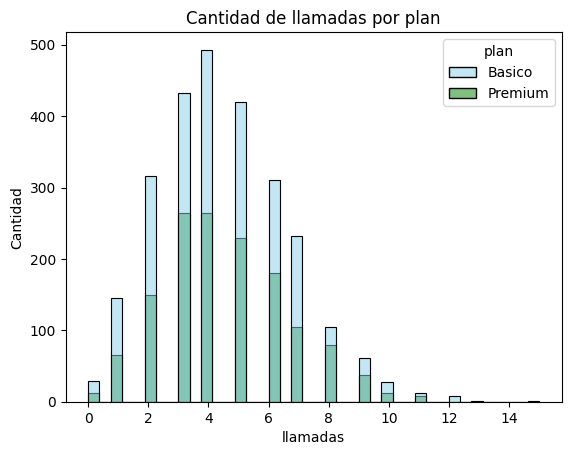

In [239]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x= "cant_llamadas", hue="plan", palette=["skyblue", "green"])
plt.title("Cantidad de llamadas por plan")
plt.xlabel("llamadas")
plt.ylabel("Cantidad")
plt.show()

💡Insights: 
- Distribución en ambos planes es muy pareja.

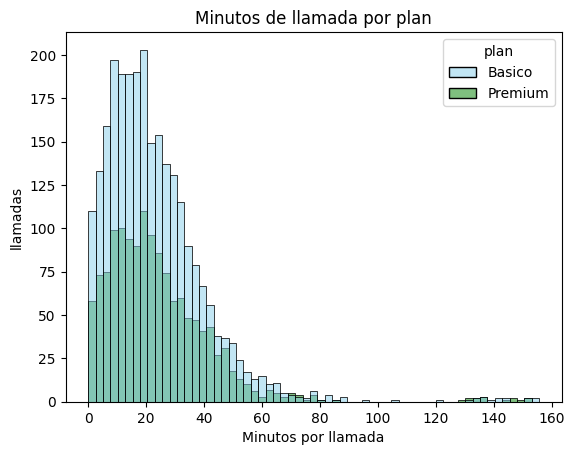

In [240]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x= "cant_minutos_llamada", hue="plan", palette=["skyblue", "green"])
plt.title("Minutos de llamada por plan")
plt.xlabel("Minutos por llamada")
plt.ylabel("llamadas")
plt.show()

💡Insights: 
- la distribución cambia a diferencia de los ejemplos pasadas, valores se encuentran sesgados a la izquierda.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

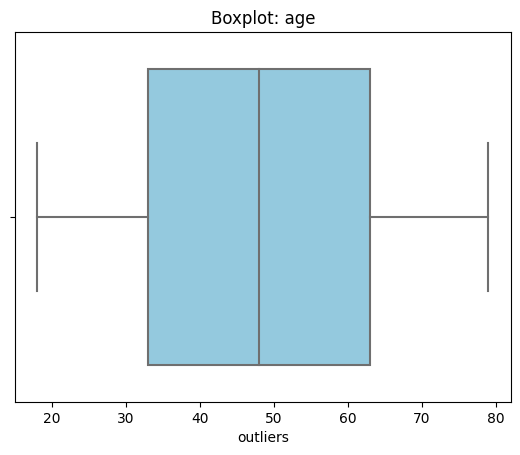

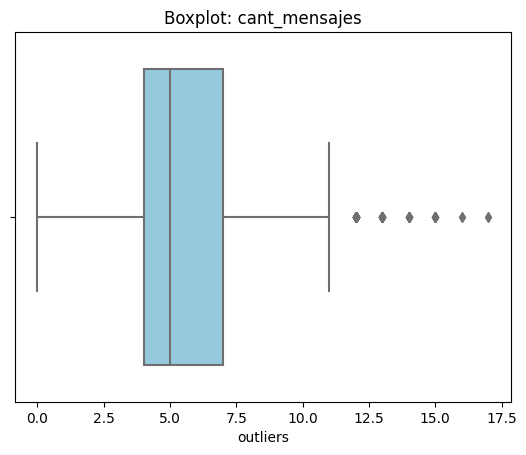

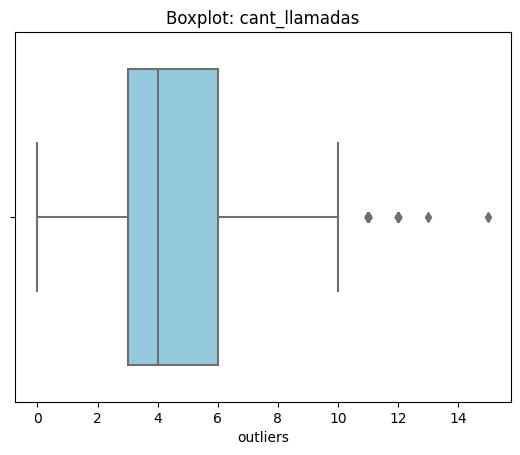

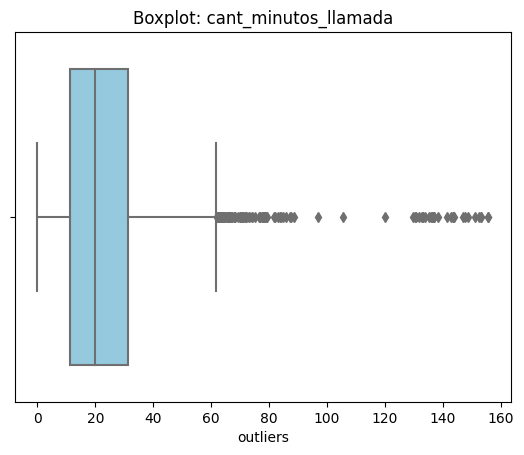

In [241]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_numericas:
        sns.boxplot(x=user_profile[col], color ="skyblue")
        plt.title(f"Boxplot: {col}")
        plt.xlabel("outliers")
        plt.show()


💡Insights: 
- Age: no tiene outliers porque -999 ya se había correjido
- cant_mensajes: tiene valores atípicso fuer de los bigotes del lador derecho, puede representa casos real de usuarios que mas mensajes mandan, deberian de caparse mediante .clip
- cant_llamadas: de igual manera la cantidad de llamadas sersan capadas.
- cant_minutos_llamada: aquí esta la mayor cantidad de valores atípicos, los mantendre como eventos real de usuarios que mas usan los minutos de llamada.

In [242]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
        Q1 = user_profile[col].quantile(0.25)
        print(f"{col}  Primer cuartil: ", Q1)
        Q3 = user_profile[col].quantile(0.75)
        print(f"{col} Tercer caurtil: ", Q3)
        IQR = Q3 - Q1
        print(f"{col} IQR: ", IQR)
    



cant_mensajes  Primer cuartil:  4.0
cant_mensajes Tercer caurtil:  7.0
cant_mensajes IQR:  3.0
cant_llamadas  Primer cuartil:  3.0
cant_llamadas Tercer caurtil:  6.0
cant_llamadas IQR:  3.0
cant_minutos_llamada  Primer cuartil:  11.12
cant_minutos_llamada Tercer caurtil:  31.415
cant_minutos_llamada IQR:  20.295


In [243]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué
- Si mantener y capar para estandarizar el analisis y manejar mejor la información.

- cant_llamadas: mantener o no outliers, porqué?
- Mantener y capar para considerar los valores atípicos dentro de un rango dentro de los parametros.

- cant_minutos_llamada: mantener o no outliers, porqué?
- mantenerlos como casos reales, usuarios que mas tiempo por llamada usan.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [244]:
# Crear columna grupo_uso


condiciones = [
    (user_profile["cant_llamadas"] <5) & (user_profile["cant_mensajes"] <5),
    (user_profile["cant_llamadas"] <10) & (user_profile["cant_mensajes"] <10),
    ]
resultados = ["Bajo uso", "Uso medio",]

user_profile["grupo_uso"] = np.select(condiciones, resultados, default="Alto uso")



In [245]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [246]:

# Crear columna grupo_edad
condiciones = [
    (user_profile["age"] <30),
    (user_profile["age"] <60),
    ]
resultados = ["Joven", "Adulto"]

user_profile["grupo_edad"] = np.select(condiciones, resultados, default="Adulto Mayor")


In [247]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

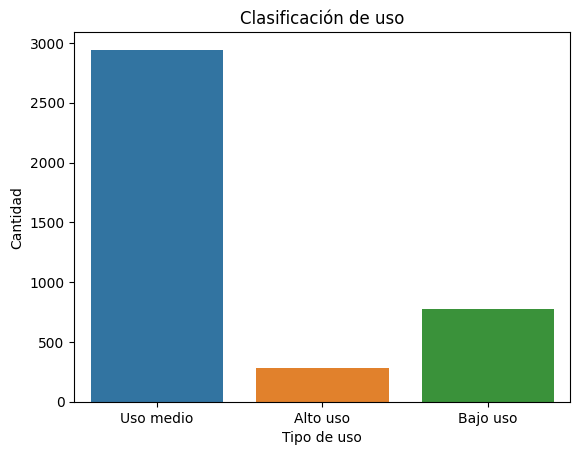

In [248]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso")
plt.title("Clasificación de uso")
plt.xlabel("Tipo de uso")
plt.ylabel("Cantidad")
plt.show()

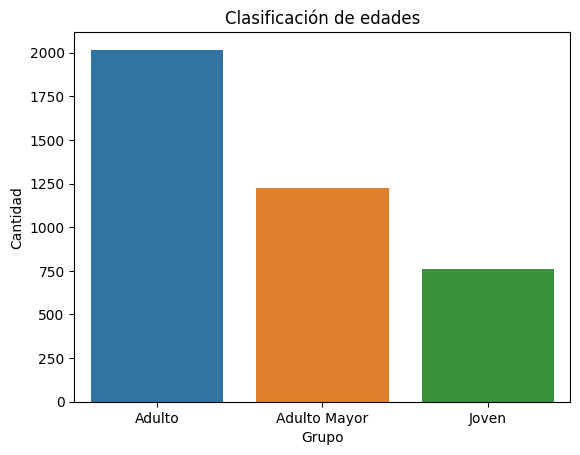

In [249]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad")
plt.title("Clasificación de edades")
plt.xlabel("Grupo")
plt.ylabel("Cantidad")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

- limpieza de datos, datos nulos y sentinels. estandarice la columna date con pd.to_datetime y seleccione el año con dt.year, en la columna age y  se corrigieron los valores fuera de rango, columna city se corrigieron valores invalidos

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

- por edades clasificandolos en : "Adulto" "Adulto Mayor y "Joven" y por consumo clasificandolos en: "Uso medio", "Bajo uso" y "Alto uso" y también por eñl tipo de plan.

- El 65 % de los usuarios tiene un plan básico.


- La mayoría de
 los clientes se encuentran entre los 30 y 60 años de edad.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

- los usuarios del plan básico por que es donde se encuentra la mayoria de los clientes, y posibles clientes para complementos del plan básico.

     
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

- hay valores extremos a la derecha, por fuera de los bigotes del gráfico, a pesar de existir no afectan al análisis, ya sea por no ser tantos o porque no se les puede considerar una actividad propia de un cliente vip en el caso de la cantidad de minutos por llamada.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

- Planes que ofrezcan más datos para navegar en internet, menos minutos de llamadas, más datos. mas beneficios de un plan premium y buscar atraer mas clientes al ese plan.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Detección de valores nulos, valores invalidos, sentinels. limpieza de datos aplicada. 
- Detección de outliers e interpretación.


🔍 **Segmentos por Edad**
- usuarios por edad y plan: cliente promedio 49 años plan básico
- clasificación de usuarios por edad: cliente adulto en un rango de edad entre >30 y <60.


📊 **Segmentos por Nivel de Uso**
- segmento por nivel de consumo: el promedio de clientes tiene un consumo medio.
- segmeto por minutos de llamada por plan: las llamadas entre el plan básico y el premium llevan una relación casi exacta.


➡️ Esto sugiere que el uso de llamadas en celulares es cada vez menor, los clientes cada vez mas optan por textear y eso se nota en las nuevas generaciones, mismsa que en unos años se convertiran al grupo de adultos


💡 **Recomendaciones**
- incentivar al cliente a planes premium ofreciendo un tarifa preferencial para datos extras.
- planes con mas datos que tiempo aire para llamadas.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`